<a href="https://colab.research.google.com/github/sizakia/Praktikum-Analisis-Deret-Waktu/blob/main/Tugas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [298]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1044)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5*44
beta0 = 10+44
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


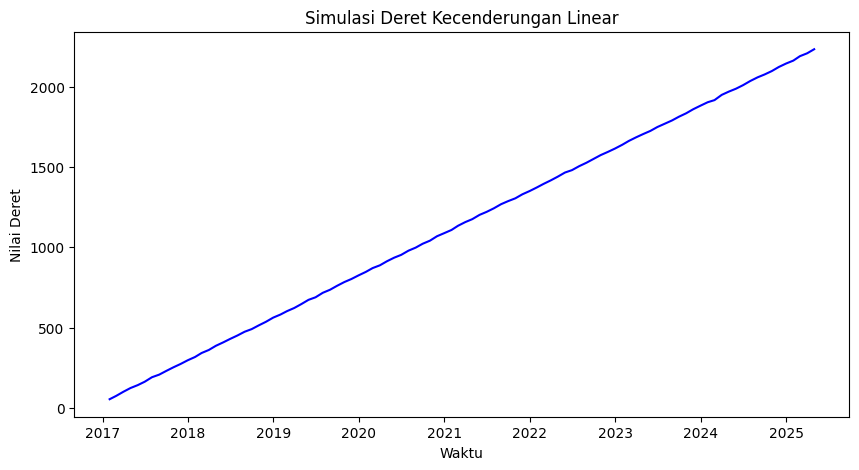

In [299]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Interpretasi:**

Berdasarkan plot di atas, dapat terlihat tren linier yang meningkat secara konsisten dari tahun 2017 hingga 2025. Tidak adanya fluktuasi acak maupun pola musiman karena pengaruh tren yang kuat dengan kemiringan $\beta_1 = 22$. Sehingga menunjukkan bahwa deret waktu tersebut tidak stasioner dalam rata-rata.

**Cek apakah ada korelasi antar pengamatan?**

In [300]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


**Kesimpulan:**

Iya, dengan Nilai korelasi diperoleh sebesar 1.0000 artinya terdapat korelasi yang kuat dan positif. Seperti pada plot sebelumnya, Pergerakan data deret waktu ini bersifat sangat deterministik dan sepenuhnya didominasi oleh komponen tren, di mana berjalannya waktu selalu diikuti oleh peningkatan nilai secara konstan dan proporsional.

In [301]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.518e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.72e-244
Time:                        16:33:19   Log-Likelihood:                -218.60
No. Observations:                 100   AIC:                             441.2
Df Residuals:                      98   BIC:                             446.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           54.0458      0.432    125.155   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**

**Apakah model regresi yang dipaskan sudah bagus?**

Berdasarkan hasil regresi OLS, model yang diperoleh:

$\hat{\mathrm{Y}}_t = 54{,}0458 + 21{,}9948Time_t$

Berdasarkan hasil pengepasan model regresi OLS, diperoleh estimasi parameter seperti di atas, sedangkan parameter asli yang digunakan dalam data simulasi adalah $\beta_0 = 54$ dan $\beta_1 = 22$. Hasil estimasi sangat dekat dengan nilai parameter asli, dengan selisih masing-masing sebesar 0,0458 dan 0,0052. Hal ini menunjukkan bahwa model regresi mampu mengestimasi parameter asli dengan sangat baik/bagus meskipun data mengandung noise acak. Dengan demikian, hasil pengepasan model OLS dapat dikatakan sangat akurat dalam merepresentasikan model pembangkitan data.

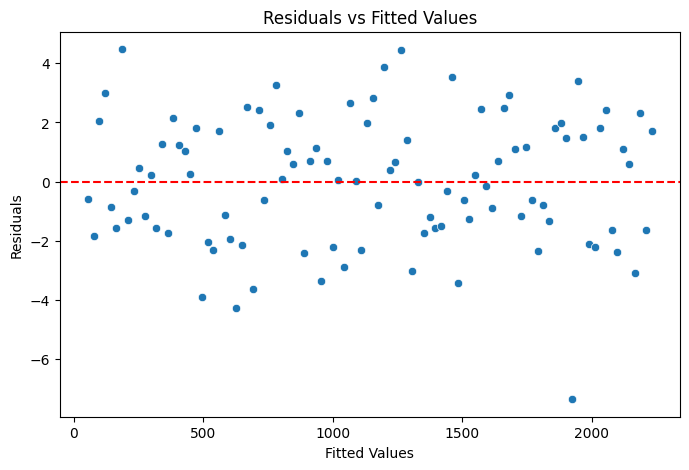

In [302]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

**Interpretasi:**

Berdasarkan plot Residuals vs Fitted Values tersebut, titik-titik residual tersebar di sekitar garis nol secara cukup acak dan tidak membentuk pola tertentu seperti pola kipas, lengkung, atau tren. Hal ini menunjukkan bahwa asumsi linearitas dan homoskedastisitas secara visual cukup terpenuhi. Namun, terlihat beberapa titik yang memiliki residual cukup ekstrem, terutama satu titik dengan residual sekitar −7, yang berpotensi menjadi pencilan (outlier). Secara keseluruhan, residual relatif tersebar di sekitar nol sehingga model regresi dapat dikatakan cukup baik berdasarkan plot residual, meskipun keberadaan outlier tersebut perlu diperhatikan.

In [303]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4980


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Hipotesis:

H₀: Tidak terdapat heteroskedastisitas (homoskedastisitas).

H₁: Terdapat heteroskedastisitas.

**Kesimpulan:**
Berdasarkan uji Breusch-Pagan diperoleh nilai p-value sebesar 0,4980 > 0,05. Oleh karena itu, H₀ gagal ditolak, sehingga dapat disimpulkan bahwa residual model tidak mengalami heteroskedastisitas atau memiliki varians yang konstan (homoskedastisitas).

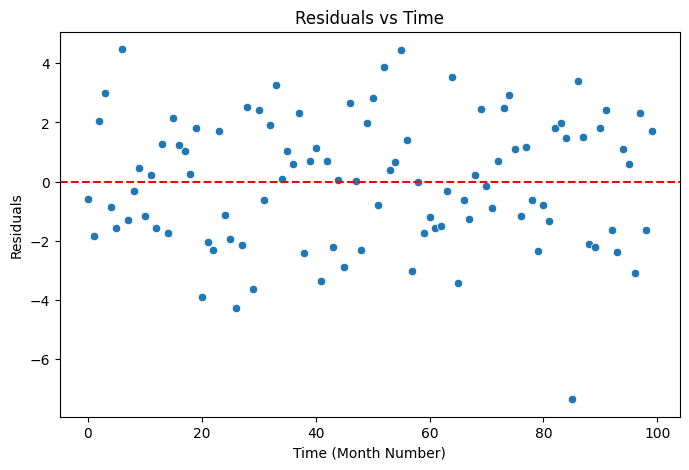

In [304]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

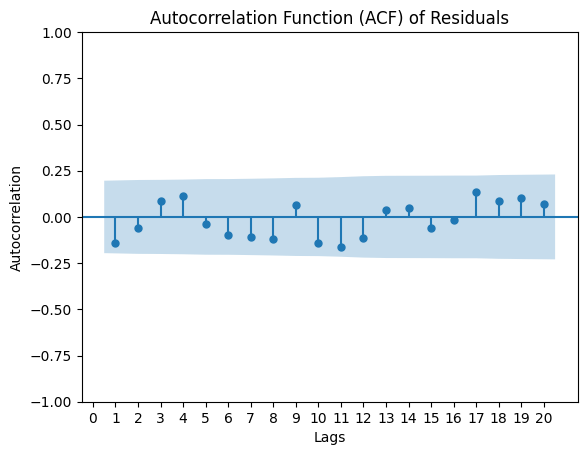

In [305]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

**Kesimpulan:**
Berdasarkan plot Residuals vs Time dan ACF residual, residual model tersebar secara acak di sekitar nilai nol dan tidak menunjukkan pola sistematis. Selain itu, nilai ACF pada lag 1–20 berada dalam batas interval kepercayaan, Karena tidak ada satupun lag yang melewati batas signifikan tersebut, maka tidak terdapat ketergantungan antara sisaan pada suatu periode dengan sisaan di periode-periode sebelumnya. Sehingga sisaan yang dihasilkan sepenuhnya memenuhi asumsi saling bebas (independen). Dengan demikian, asumsi independensi residual dapat dianggap terpenuhi. Terdapat satu pengamatan ekstrem pada residual sekitar periode ke-85 yang perlu diperiksa lebih lanjut sebagai kemungkinan outlier.

In [306]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    2.066326   0.150584
2    2.426896   0.297171
3    3.254689   0.353999
4    4.655742   0.324478
5    4.820595   0.438165
6    5.817459   0.443946
7    7.052258   0.423459
8    8.671427   0.370767
9    9.125276   0.425791
10  11.346117   0.331196
11  14.371490   0.213115
12  15.867565   0.197377
13  16.045899   0.246660
14  16.294910   0.295698
15  16.702908   0.336933
16  16.741125   0.402537
17  18.939013   0.332044
18  19.817356   0.343196
19  21.120015   0.330207


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

Hipotesis:

H₀: tidak terdapat autokorelasi residual hingga lag tertentu.

H₁: terdapat autokorelasi residual.

**Kesimpulan:**
Berdasarkan output uji Ljung-Box dapat dilihat bahwa seluruh nilai p-value dari lag ke-1 hingga ke-19 secara konsisten bernilai lebih besar dari taraf nyata 5% ( α=0,05 ), dengan nilai p-value terkecil sebesar 0,1506 pada lag pertama. Karena p-value >  α , maka hipotesis nol gagal ditolak, sehingga dapat disimpulkan cukup bukti bahwa tidak terdapat autokorelasi yang signifikan pada residual model hingga lag 19. Dengan demikian, residual model dapat dianggap bersifat independen (white noise) dan asumsi tidak adanya autokorelasi telah terpenuhi.

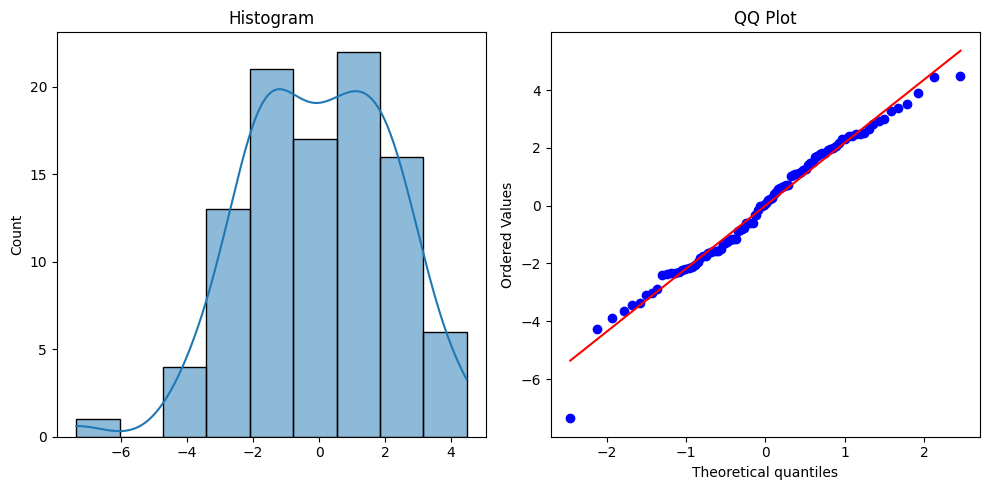

In [307]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**

**Kesimpulan:**
Berdasarkan histogram dan QQ Plot, residual model secara umum dapat dianggap berdistribusi normal karena sebagian besar titik pada QQ Plot mengikuti garis diagonal dan histogram memiliki bentuk yang relatif menyerupai distribusi normal. Namun, terdapat sedikit penyimpangan pada bagian ekor akibat adanya nilai ekstrem. Dengan demikian, asumsi normalitas residual secara umum dapat dianggap terpenuhi, tetapi pengamatan ekstrem tersebut perlu diperhatikan.

In [308]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9827031980402805, p-value = 0.21461893946073846


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?**

Hipotesisnya:

H₀: Residual berdistribusi normal.

H₁: Residual tidak berdistribusi normal.

**Kesimpulan:**

Berdasarkan uji Shapiro-Wilk, diperoleh p-value sebesar 0,2146 yang lebih besar dari 0,05. Oleh karena itu, H₀ gagal ditolak, sehingga tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal. Artinya, Ya, sama. Dari Histogram dan QQ Plot sebelumnya, sebagian besar residual terlihat mengikuti pola distribusi normal dan titik-titik pada QQ Plot berada cukup dekat dengan garis diagonal. Jadi, baik secara visual (plot) maupun statistik (Shapiro-Wilk), kesimpulannya adalah asumsi normalitas residual terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [309]:
# Menentukan parameter simulasi
np.random.seed(1044)
n_periods = 120
beta_0, beta_1, beta_2= 50+44, 0.5*44, 0.02*44
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

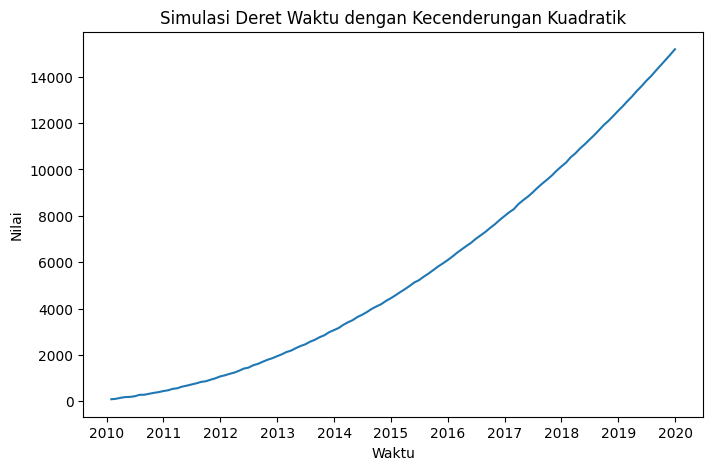

In [310]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

**Interpretasi:**

Berdasarkan plot deret waktu dengan kecenderungan kuadratik tersebut, dapat dilihat bahwa pola data mengalami kenaikan yang semakin cepat dari waktu ke waktu, deret dengan kecenderungan kuadratik menunjukkan pola peningkatan yang tidak konstan. Hal ini terlihat dari bentuk grafik yang melengkung ke atas. Berbeda dengan kecenderungan linear yang membentuk garis lurus dengan laju peningkatan relatif konstan, kecenderungan kuadratik memiliki laju pertumbuhan yang semakin besar karena adanya komponen kuadrat $t^2$.

In [311]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.117e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.14e-309
Time:                        16:33:21   Log-Likelihood:                -449.80
No. Observations:                 120   AIC:                             905.6
Df Residuals:                     117   BIC:                             914.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         94.5439      2.802     33.740      0.0

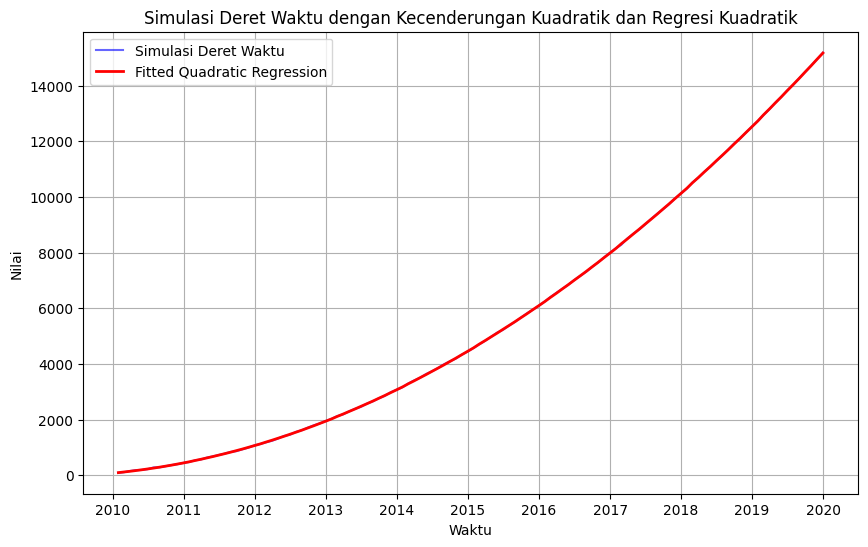

In [312]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**


Model yang diperoleh adalah:

$Y_t = 94.543 + 21.9498t + 0.8803t^2 + \epsilon_t$

Sedangkan parameter asli yang digunakan saat simulasi adalah:

$$ \beta_0=94,\qquad \beta_1=22,\qquad \beta_2=0.88 $$

Nilai hasil estimasi sangat dekat dengan parameter asli. Ini artinya model kuadratik berhasil menangkap pola sebenarnya dari deret.

Dari output diperoleh:

$$ \text{Prob(JB)}=0.463>0.05 $$

Sehingga tidak terdapat bukti yang cukup bahwa residual tidak berdistribusi normal. Dengan demikian, asumsi normalitas residual dapat dianggap terpenuhi.

Nilai Durbin-Watson:

$$ DW=2.274 $$

Nilai tersebut cukup dekat dengan 2, sehingga tidak menunjukkan adanya autokorelasi yang serius pada residual.

**Kesimpulan:**

Berdasarkan hasil pengepasan regresi kuadratik, model yang diperoleh dapat dikatakan tepat dalam menggambarkan deret waktu. Hal ini ditunjukkan oleh nilai estimasi parameter yang sangat dekat dengan parameter asli, yaitu $\beta_0=94$, $\beta_1=22$, dan $\beta_2=0.88$. Selain itu, seluruh parameter signifikan dan model memiliki nilai $R^2$ sebesar 1,000. Hasil diagnostik juga menunjukkan bahwa residual secara umum memenuhi asumsi normalitas dan tidak menunjukkan autokorelasi yang signifikan. Dengan demikian, model regresi kuadratik mampu merepresentasikan pola kecenderungan kuadratik pada deret dengan baik. Namun, asumsi homoskedastisitas perlu dikonfirmasi melalui uji Breusch-Pagan pada model kuadratik.

In [313]:
# cek asumsi model regresi kuadratik
# Uji Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(model_quad.resid, model_quad.model.exog)

print(f"LM Statistic: {bp_test[0]:.4f}")
print(f"P-value: {bp_test[1]:.4f}")

LM Statistic: 2.0429
P-value: 0.3601


**Interpretasi:**

Untuk uji Breusch-Pagan, bandingkan p-value dengan α = 0,05:

$$ 0,3601 > 0,05 $$

Maka H₀ gagal di ditolak.

**Kesimpulan:** Tidak terdapat heteroskedastisitas pada residual model regresi kuadratik. Dengan demikian, asumsi homoskedastisitas terpenuhi.

In [314]:
# Uji Ljung-Box untuk autokorelasi residual
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(
    model_quad.resid,
    lags=range(1, 20),
    return_df=True
)

print(ljung)

      lb_stat  lb_pvalue
1    2.464620   0.116436
2    2.994398   0.223756
3    3.399330   0.334055
4    5.844314   0.211081
5    6.119497   0.294764
6    7.303004   0.293732
7    8.376432   0.300573
8    9.822594   0.277699
9   10.602458   0.303945
10  13.199932   0.212707
11  18.187083   0.077340
12  19.193349   0.083968
13  19.890277   0.097980
14  20.445546   0.116709
15  21.867846   0.111316
16  21.875865   0.147245
17  25.316760   0.087841
18  26.150055   0.096376
19  26.150145   0.126059


**Interpretasi:**

Berdasarkan uji Ljung-Box pada lag 1 hingga 19, seluruh p-value lebih besar dari 0,05. Oleh karena itu, H₀ gagal ditolak, sehingga tidak terdapat bukti yang cukup adanya autokorelasi pada residual hingga lag 19. Dengan demikian, residual model regresi kuadratik dapat dianggap tidak mengalami autokorelasi, sehingga asumsi independensi residual terpenuhi.

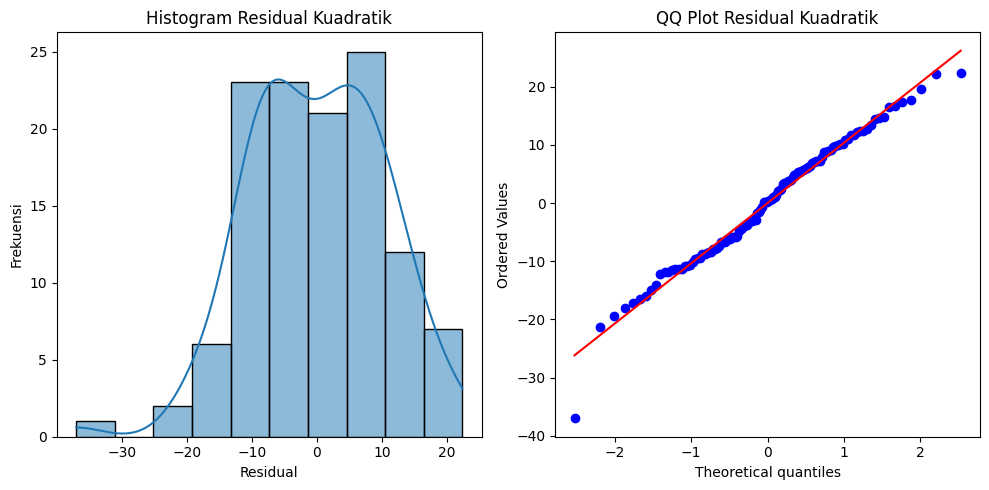

In [315]:
# Histogram dan QQ Plot Residual Model Kuadratik
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Histogram
sns.histplot(model_quad.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram Residual Kuadratik')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frekuensi')

# QQ Plot
stats.probplot(model_quad.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot Residual Kuadratik')

plt.tight_layout()
plt.show()

In [316]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model_quad.resid)

print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat:.4f}, p-value = {shapiro_p_value:.4f}")

Shapiro-Wilk Test: Statistics = 0.9846, p-value = 0.1904


**Kesimpulan:**

Berdasarkan uji Shapiro-Wilk diperoleh p-value sebesar 0,1904 > 0,05. Oleh karena itu, $H_0$ gagal ditolak, sehingga tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal. Dengan demikian, residual pada model regresi kuadratik dapat dianggap berdistribusi normal, sehingga asumsi normalitas residual terpenuhi.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [317]:
# Menentukan parameter simulasi
np.random.seed(1044)
n_periods = 120
beta0, beta1, beta2=50+44,-25*44, -2*44
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


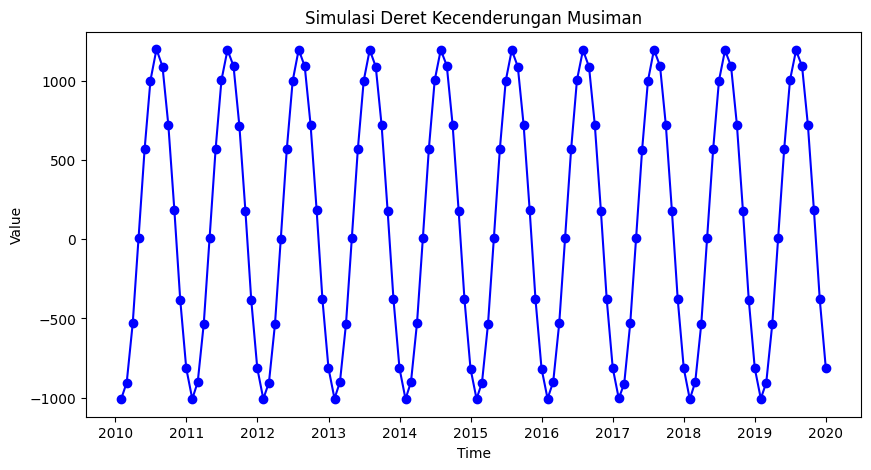

In [318]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

**Interpretasi:**

Berdasarkan grafik, deret waktu menunjukkan pola musiman yang kuat dengan periode musiman 12 bulan. Pola naik dan turun berulang secara konsisten setiap tahun, misal ketika awal tahun rendah dan di pertengahan tahun tingi. dengan nilai maksimum sekitar 1.200 dan minimum sekitar −1.000. Deret tidak menunjukkan adanya tren jangka panjang, sehingga perubahan nilai terutama disebabkan oleh komponen musiman. Variasi kecil di sekitar pola musiman berasal dari noise acak. Dengan demikian, deret tersebut dapat dikatakan memiliki karakteristik musiman yang kuat dengan siklus berulang setiap 12 periode.

In [319]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [320]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [321]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [322]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.531e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.59e-275
Time:                        16:33:22   Log-Likelihood:                -252.00
No. Observations:                 120   AIC:                             528.0
Df Residuals:                     108   BIC:                             561.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1006.9255      0.659  -1528.790      0.0

Bagaimana interpretasi dari hasil tersebut?

**Interpretasi:**

Berdasarkan hasil regresi dengan dummy variabel musiman, diperoleh R-squared sebesar 1,000 yang menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data. Uji F menghasilkan p-value sebesar 5,59 × 10⁻²⁷⁵ < 0,05, sehingga dapat disimpulkan bahwa variabel dummy musiman secara simultan berpengaruh signifikan terhadap deret. Seluruh koefisien dummy juga signifikan secara statistik. Pola musiman menunjukkan nilai terendah terjadi pada Januari sebesar -1006,93 dan nilai tertinggi pada Juli sebesar 1194,26. Nilai Durbin-Watson sebesar 2,259 menunjukkan tidak adanya indikasi kuat autokorelasi residual, sedangkan uji Jarque-Bera dengan p-value 0,680 menunjukkan bahwa residual dapat dianggap berdistribusi normal. Dengan demikian, model dummy musiman mampu merepresentasikan pola musiman 12 bulanan pada deret dengan sangat baik.

In [323]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

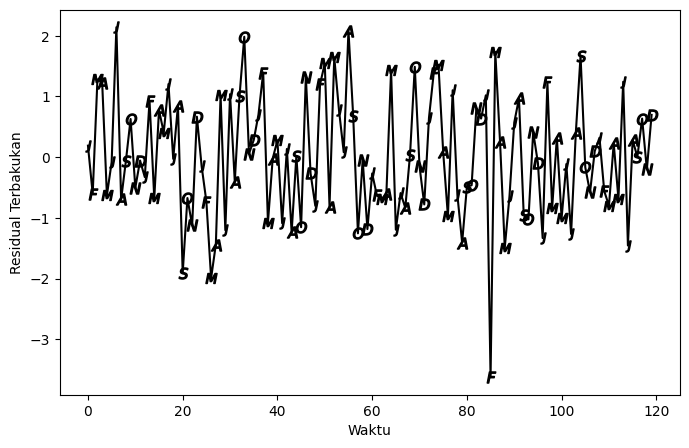

In [324]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


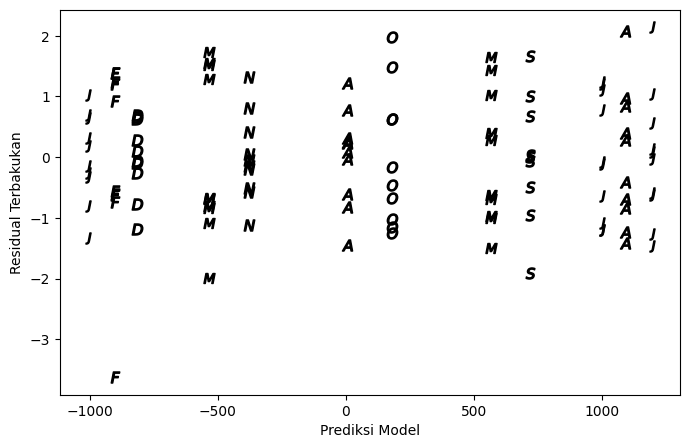

In [325]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

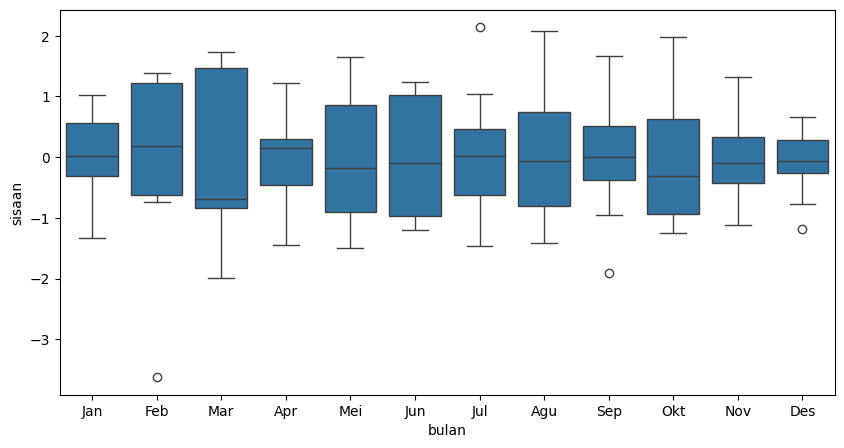

In [326]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

**Interpretasi:**

Berdasarkan ketiga plot sisaan terbakukan, residual model secara umum tersebar di sekitar nilai nol dan tidak menunjukkan pola sistematis terhadap waktu maupun nilai prediksi. Penyebaran residual antarbulan juga relatif serupa, sehingga secara visual tidak terdapat indikasi kuat adanya masalah pada model. Hal ini menunjukkan bahwa model regresi dengan dummy musiman telah mampu menangkap pola musiman 12 bulanan dengan baik. Meskipun demikian, terdapat beberapa observasi ekstrem yang perlu diperiksa lebih lanjut karena dapat memberikan pengaruh terhadap hasil model.

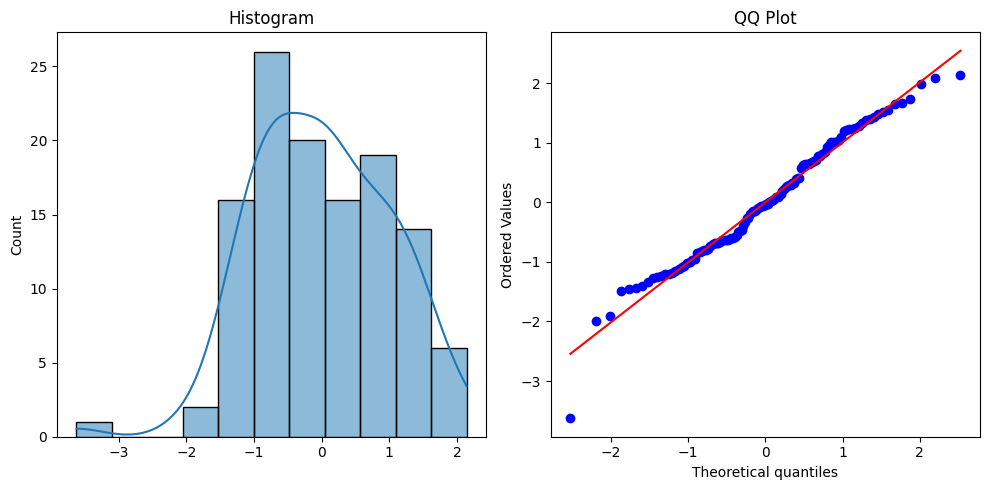

In [327]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

**Interpretasi:**

Berdasarkan histogram dan QQ Plot, residual model musiman secara umum menunjukkan pola distribusi yang mendekati normal. Sebagian besar residual berada di sekitar nilai nol dan titik-titik pada QQ Plot mengikuti garis diagonal. Meskipun terdapat satu observasi ekstrem pada bagian ekor kiri, secara visual asumsi normalitas residual masih dapat dianggap terpenuhi. Hasil ini selanjutnya dapat dikonfirmasi melalui uji Shapiro-Wilk.

In [328]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep
# Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(musiman.resid)

print("=== Shapiro-Wilk Test ===")
print(f"Statistics = {shapiro_stat:.4f}")
print(f"P-value = {shapiro_p:.4f}")

=== Shapiro-Wilk Test ===
Statistics = 0.9800
P-value = 0.0705


**Interpretasi:**

Berdasarkan uji Shapiro-Wilk diperoleh statistik sebesar 0,9800 dengan p-value sebesar 0,0705. Karena p-value > 0,05, maka $H_0$ gagal ditolak. Dengan demikian, tidak terdapat bukti yang cukup bahwa residual tidak berdistribusi normal, sehingga residual pada model musiman tanpa intersep dapat dianggap berdistribusi normal. Dengan demikian, asumsi normalitas residual terpenuhi.


In [329]:
#Ljung-Box
ljung_box_test = acorr_ljungbox(
    musiman.resid,
    lags=range(1,13),
    return_df=True
)
print(ljung_box_test)

      lb_stat  lb_pvalue
1    2.130367   0.144406
2    2.203129   0.332351
3    2.778354   0.427076
4    4.805622   0.307830
5    5.362041   0.373311
6    5.556679   0.474633
7    6.945418   0.434585
8    9.432115   0.307164
9   10.081337   0.343941
10  11.790253   0.299339
11  15.439953   0.163228
12  19.548677   0.076120


**Interpretasi:**

Berdasarkan uji Ljung-Box pada lag 1 hingga 12, seluruh p-value lebih besar dari taraf signifikansi 5%. Dengan demikian, $H_0$ gagal ditolak, sehingga tidak terdapat bukti yang cukup adanya autokorelasi pada residual hingga lag 12. Oleh karena itu, residual model dapat dianggap tidak mengalami autokorelasi yang signifikan dan asumsi independensi residual terpenuhi.

In [330]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [331]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.531e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          5.59e-275
Time:                        16:33:24   Log-Likelihood:                -252.00
No. Observations:                 120   AIC:                             528.0
Df Residuals:                     108   BIC:                             561.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1006.9255      0.659  -1528.790      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

**Kesimpulan:**
Berdasarkan hasil pengepasan model regresi musiman dengan intersep, diperoleh $R^2=1,000$, yang menunjukkan bahwa model mampu menjelaskan variasi data dengan sangat baik. Model menggunakan Januari sebagai kategori referensi, sehingga nilai intersep sebesar -1006,9255 menunjukkan rata-rata nilai $Y_t$ pada bulan Januari. Sementara itu, koefisien dummy bulan lainnya menunjukkan perbedaan rata-rata nilai $Y_t$ pada bulan tersebut terhadap bulan Januari. Sebagai contoh, koefisien Juli sebesar 2201,1864 menunjukkan bahwa nilai pada bulan Juli rata-rata 2201,1864 lebih tinggi dibandingkan Januari. Jika intersep dan koefisien dummy dijumlahkan, diperoleh nilai rata-rata bulan tersebut, sehingga hasil prediksi model dengan intersep sama dengan model tanpa intersep.

Berdasarkan pemeriksaan asumsi, residual model berdistribusi normal karena diperoleh p-value Jarque-Bera sebesar 0,680 > 0,05. Nilai Durbin-Watson sebesar 2,259 dan hasil uji Ljung-Box hingga lag 12 yang memiliki p-value > 0,05 menunjukkan tidak terdapat bukti autokorelasi residual. Dengan demikian, asumsi normalitas dan independensi residual terpenuhi. Asumsi homoskedastisitas masih perlu dikonfirmasi menggunakan uji Breusch-Pagan pada model dengan intersep.

In [332]:
# uji asumsi model dengan intersep
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox

# 1. Uji Normalitas (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(musiman_int.resid)

print("=== Shapiro-Wilk Test ===")
print(f"Statistics = {shapiro_stat:.4f}")
print(f"P-value = {shapiro_p:.4f}")


# 2. Uji Heteroskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(
    musiman_int.resid,
    musiman_int.model.exog
)

print("\n=== Breusch-Pagan Test ===")
print(f"LM Statistic = {bp_test[0]:.4f}")
print(f"P-value = {bp_test[1]:.4f}")


# 3. Uji Autokorelasi (Ljung-Box)
ljung_box = acorr_ljungbox(
    musiman_int.resid,
    lags=12,
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_box)

=== Shapiro-Wilk Test ===
Statistics = 0.9800
P-value = 0.0705

=== Breusch-Pagan Test ===
LM Statistic = 14.7560
P-value = 0.1939

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
1    2.130367   0.144406
2    2.203129   0.332351
3    2.778354   0.427076
4    4.805622   0.307830
5    5.362041   0.373311
6    5.556679   0.474633
7    6.945418   0.434585
8    9.432115   0.307164
9   10.081337   0.343941
10  11.790253   0.299339
11  15.439953   0.163228
12  19.548677   0.076120


**Interpretasi:**

Berdasarkan hasil pengujian asumsi model regresi dengan intersep, diperoleh p-value uji Shapiro-Wilk sebesar 0,0705 > 0,05, sehingga residual dapat dianggap berdistribusi normal. Uji Breusch-Pagan menghasilkan p-value sebesar 0,1939 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap konstan. Selanjutnya, uji Ljung-Box pada lag 1 hingga 12 menghasilkan p-value yang seluruhnya lebih besar dari 0,05, sehingga tidak terdapat bukti autokorelasi pada residual. Dengan demikian, model regresi musiman dengan intersep telah memenuhi asumsi normalitas, homoskedastisitas, dan tidak adanya autokorelasi.

## Kecenderungan Linear dan Musiman

In [333]:
# Parameter
np.random.seed(1044)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5*44, 10*44 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


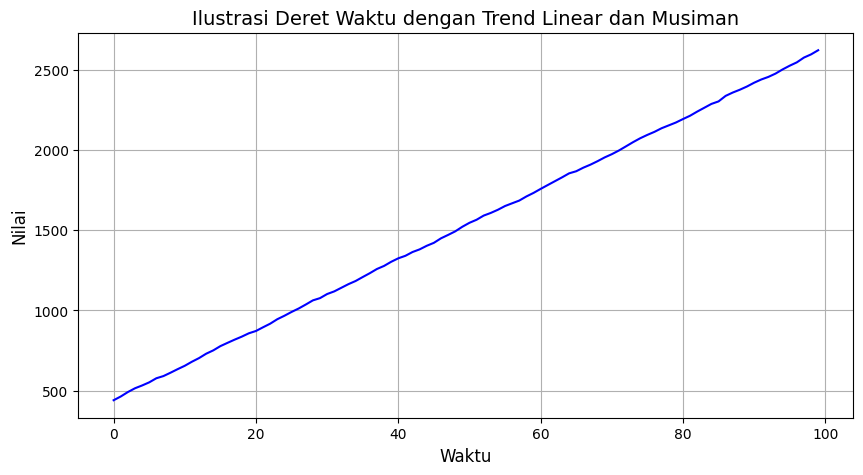

In [334]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [335]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [336]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [337]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.124e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.22e-211
Time:                        16:33:25   Log-Likelihood:                -212.46
No. Observations:                 100   AIC:                             450.9
Df Residuals:                      87   BIC:                             484.8
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      439.2605      0.809    542.876      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

**Interpretasi:**
Berdasarkan hasil pengepasan model regresi dengan komponen tren linear dan musiman, diperoleh koefisien period sebesar 21,9947 yang sangat dekat dengan parameter sebenarnya, yaitu 22. Hal ini menunjukkan bahwa nilai deret meningkat sekitar 21,9947 satuan untuk setiap kenaikan satu periode waktu. Sementara itu, koefisien dummy bulan menunjukkan adanya variasi musiman pada masing-masing bulan. Nilai koefisien musiman tertinggi terdapat pada April sebesar 445,8204, sedangkan yang terendah terdapat pada Oktober sebesar 434,3751. Seluruh koefisien memiliki p-value < 0,05 sehingga signifikan secara statistik. Dengan $R^2=1,000$, model mampu menjelaskan variasi deret dengan sangat baik dan berhasil menangkap kecenderungan tren linear sekaligus pola musiman pada data.

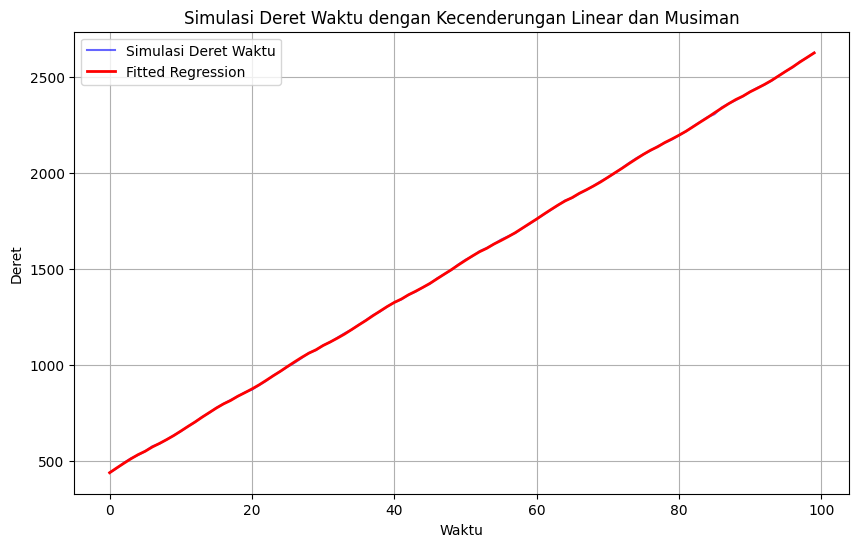

In [338]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [339]:
# uji asumsi model
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Uji Normalitas Residual - Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(model_mix.resid)

print("=== Shapiro-Wilk Test ===")
print(f"Statistics = {shapiro_stat:.4f}")
print(f"P-value = {shapiro_p:.4f}")


# 2. Uji Homoskedastisitas - Levene
bulan = x % 12

kelompok_resid = [
    model_mix.resid[bulan == i]
    for i in range(12)
]

levene_stat, levene_p = stats.levene(
    *kelompok_resid,
    center='median'
)

print("\n=== Levene Test ===")
print(f"Statistics = {levene_stat:.4f}")
print(f"P-value = {levene_p:.4f}")


# 3. Uji Autokorelasi - Ljung-Box
ljung_box = acorr_ljungbox(
    model_mix.resid,
    lags=12,
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_box)

=== Shapiro-Wilk Test ===
Statistics = 0.9734
P-value = 0.0408

=== Levene Test ===
Statistics = 0.9402
P-value = 0.5065

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
1    1.372735   0.241342
2    1.590747   0.451413
3    2.888330   0.409165
4    3.776781   0.437057
5    3.960141   0.555169
6    4.269263   0.640289
7    6.373944   0.496826
8    8.584830   0.378519
9    9.010364   0.436318
10  11.480410   0.321334
11  13.556843   0.258492
12  19.696310   0.073053


**Interpretasi:**

Berdasarkan hasil pengujian asumsi model regresi dengan kecenderungan linear dan musiman, uji Shapiro-Wilk menghasilkan p-value sebesar 0,0408 < 0,05, sehingga terdapat indikasi bahwa residual tidak berdistribusi normal. Dengan demikian, **asumsi normalitas residual tidak terpenuhi**.

Sementara itu, uji Levene menghasilkan p-value sebesar 0,5065 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas dan asumsi homoskedastisitas terpenuhi. Hasil uji Ljung-Box pada lag 1 hingga 12 juga menunjukkan seluruh p-value > 0,05, sehingga tidak terdapat bukti autokorelasi residual.

Dengan demikian, **model hanya mengalami pelanggaran pada asumsi normalitas**, sedangkan asumsi homoskedastisitas dan tidak adanya autokorelasi terpenuhi.

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [340]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

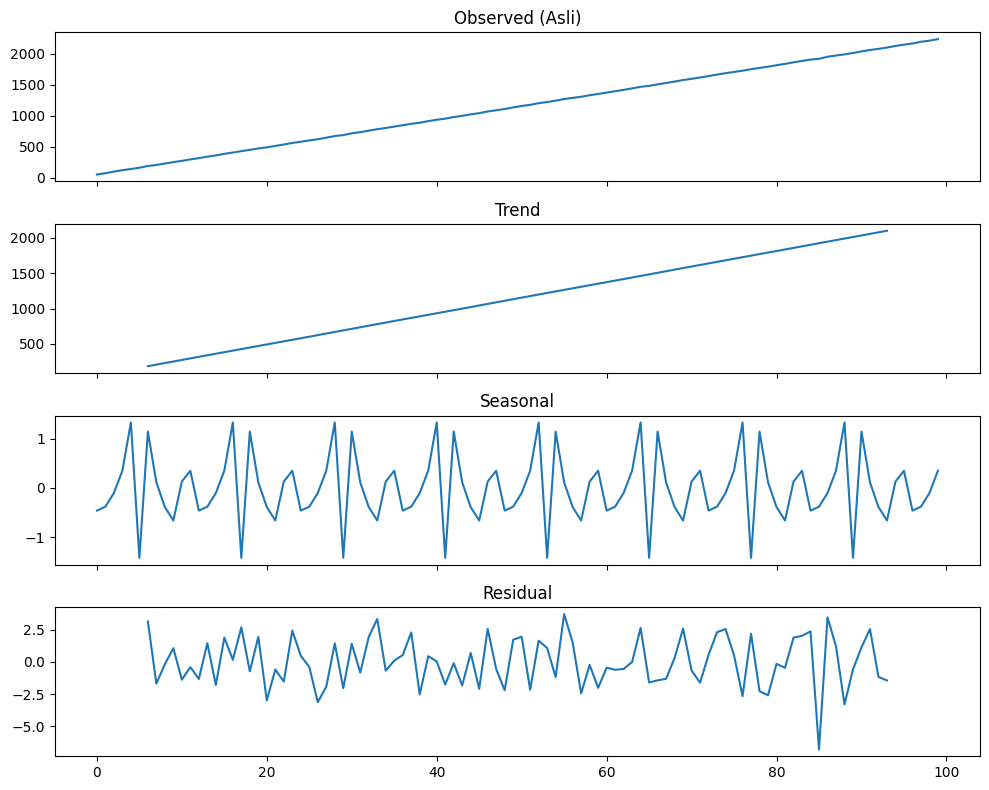

In [341]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Interpretasi:**

Berdasarkan hasil dekomposisi deret waktu dengan model aditif dan periode 12, deret terdiri atas tiga komponen utama, yaitu tren, musiman, dan residual. Komponen tren menunjukkan kecenderungan meningkat secara linear dari waktu ke waktu. Komponen musiman menunjukkan pola naik-turun yang berulang setiap 12 periode, sehingga terdapat pola musiman tahunan. Sementara itu, komponen residual berfluktuasi di sekitar nol tanpa pola sistematis yang jelas dan merepresentasikan variasi acak yang tidak dapat dijelaskan oleh tren maupun musiman. Dengan demikian, deret simulasi mengandung komponen tren linear dan komponen musiman 12 periode, sedangkan sisanya merupakan noise.

In [342]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

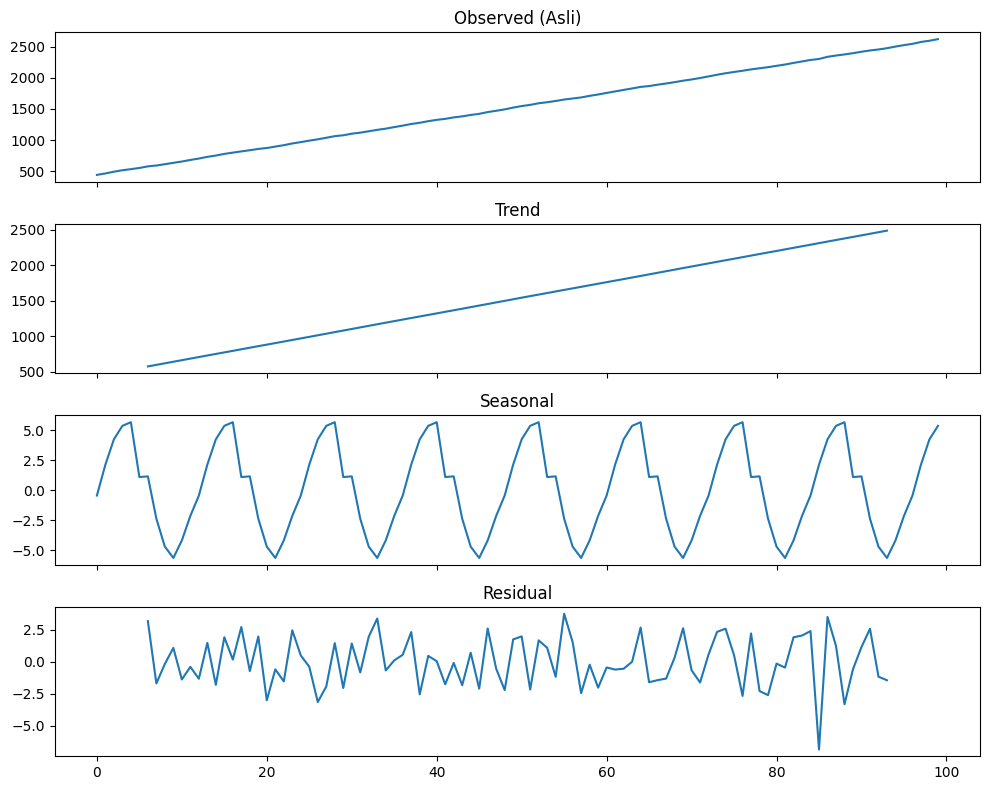

In [343]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

**Interpretasi:**

Berdasarkan hasil dekomposisi aditif dengan periode musiman 12, deret waktu menunjukkan tren meningkat secara linear yang dominan. Komponen musiman memperlihatkan pola yang berulang setiap 12 periode dengan amplitudo relatif kecil dibandingkan tren. Sementara itu, komponen residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola sistematis yang kuat, sehingga dapat diasumsikan sebagai variasi acak yang tidak dijelaskan oleh komponen tren dan musiman

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [344]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1044)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05*44, 10*44 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

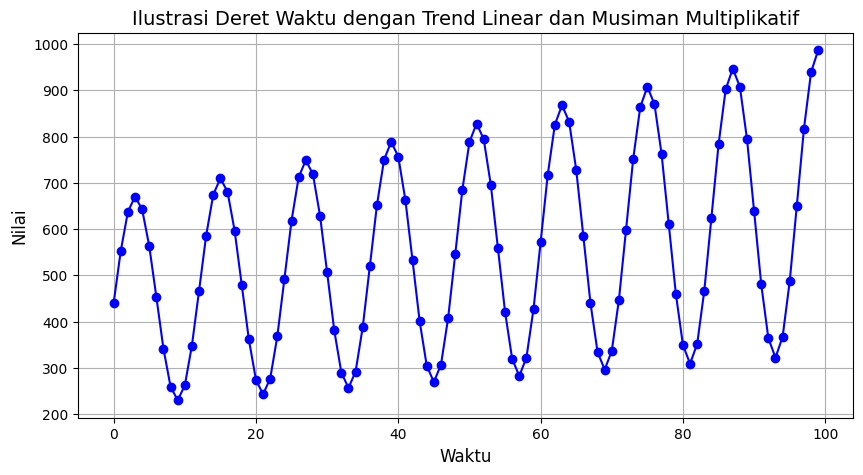

In [345]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [346]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

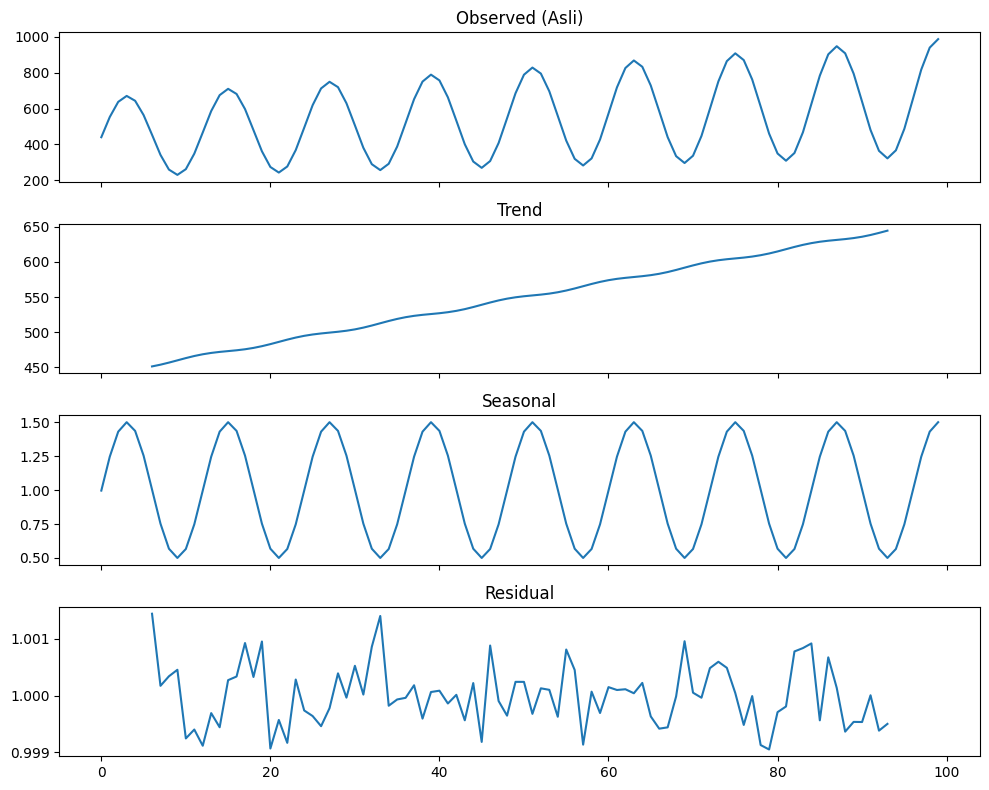

In [347]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

**Interpretasi:**

Berdasarkan hasil dekomposisi multiplikatif dengan periode 12, deret waktu menunjukkan adanya kecenderungan meningkat secara konsisten serta pola musiman yang berulang setiap 12 periode. Komponen seasonal berada pada kisaran 0,5 hingga 1,5, yang menunjukkan bahwa pengaruh musiman bersifat proporsional terhadap level trend. Ketika trend meningkat, amplitudo fluktuasi pada data observed juga semakin besar. Komponen residual berfluktuasi sangat dekat dengan nilai 1, yang menunjukkan bahwa sebagian besar variasi sistematis pada deret telah dapat dijelaskan oleh komponen trend dan seasonal. Dengan demikian, model multiplikatif sesuai untuk menggambarkan karakteristik deret tersebut.

In [348]:
# Parameter
np.random.seed(1044)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

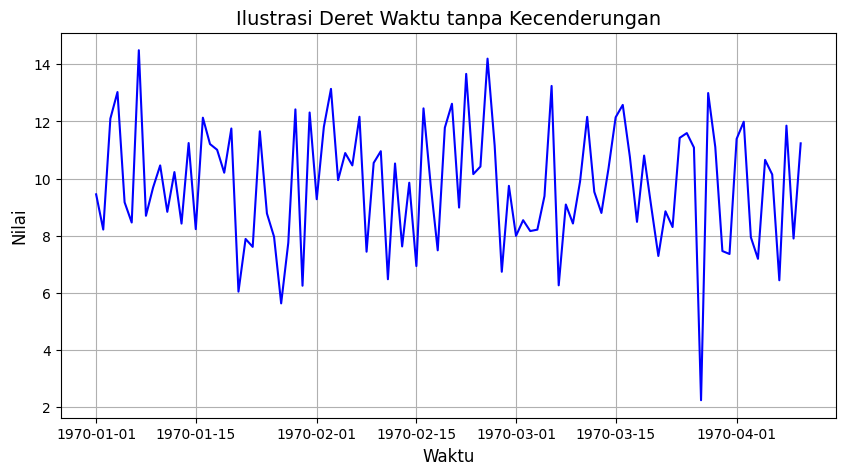

In [349]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

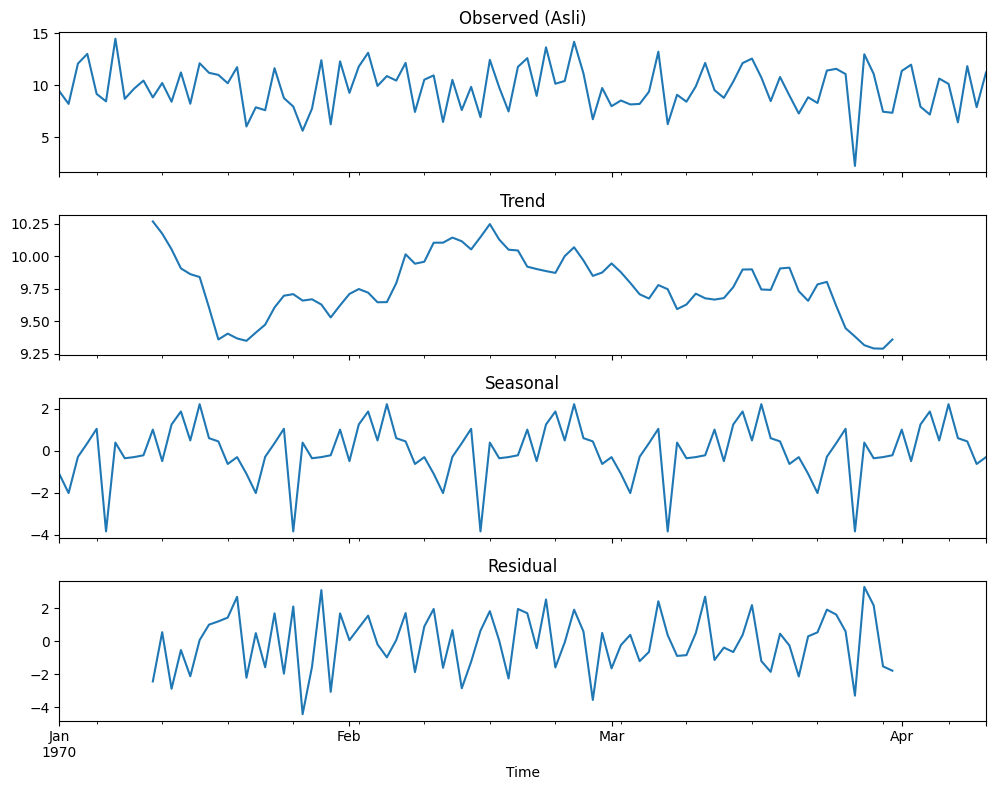

In [351]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

**Interpretasi:**

Berdasarkan hasil dekomposisi aditif dengan periode 20, data observed menunjukkan fluktuasi acak di sekitar nilai rata-rata 10 tanpa kecenderungan meningkat atau menurun secara konsisten. Komponen trend yang dihasilkan hanya menunjukkan variasi kecil akibat proses smoothing dan tidak mengindikasikan adanya trend sistematis. Komponen seasonal memperlihatkan pola berulang setiap 20 periode, tetapi pola tersebut bukan seasonalitas yang sebenarnya karena data awal hanya dibangkitkan sebagai noise acak. Sementara itu, residual berfluktuasi secara acak di sekitar nol. Dengan demikian, karakteristik utama deret adalah noise acak tanpa trend dan seasonalitas yang nyata.